# 01 - Exploratory Data Analysis (EDA)

**Phase 1** of the plan. Goals:
1. Understand the SMS Spam Collection (size, class balance, duplicates, message length).
2. Look at the most frequent words in spam vs ham.
3. Create and **persist the one train/test split** every later notebook reuses.

All figures are saved to `results/` and all summary numbers to `results/eda_summary.csv`
(no hand-typed metrics - the report reads these files).

In [1]:
import sys
from pathlib import Path

# Make the repo root importable so `import src...` works when run from notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.preprocessing import load_dataset, make_split, clean

sns.set_theme(style="whitegrid")
RESULTS = config.RESULTS_DIR
print("Results dir:", RESULTS)

Results dir: /home/sdd/Documents/ovi/final year project/results


## 1. Load the data & handle duplicates

`load_dataset()` keeps the two real columns, maps `ham->0 / spam->1`, and (by default)
drops exact-duplicate messages. Duplicates are removed **before** splitting to prevent the
same message appearing in both train and test sets (data leakage).

**Integrity check first:** the CSV has extra `Unnamed:` columns. These are *not* empty for
every row - about 50 messages contain a comma that made the parser spill their text across
those columns. Naively keeping only `v2` would silently truncate them. `load_dataset()`
instead **reconstructs** the full message by re-joining the split fields. We verify below that
every spilled message was recovered (not truncated).

In [2]:
# --- Integrity check: confirm spilled messages are reconstructed, not truncated ---
_raw_full = pd.read_csv(config.DATA_PATH, encoding="latin-1")
_extra_cols = [c for c in _raw_full.columns if c not in ("v1", "v2")]
_spill_mask = _raw_full[_extra_cols].notna().any(axis=1).values
print("Extra columns:", _extra_cols)
print("Rows whose text spilled into extra columns:", int(_spill_mask.sum()))

_check = load_dataset(drop_duplicates=False)
assert len(_check) == len(_raw_full), "row count changed; positional check invalid"
_v2_len = _raw_full["v2"].fillna("").astype(str).str.len().values
_recon_len = _check["text"].str.len().values
_recovered = (_recon_len > _v2_len)[_spill_mask]
print("Spilled rows where reconstruction recovered extra text:", int(_recovered.sum()))
assert _recovered.all(), "Some spilled rows were still truncated!"
print("OK: all spilled messages reconstructed, none truncated.")
print("\nExample reconstructed message:\n", _check["text"].values[_spill_mask][0][:200])

Extra columns: ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4']
Rows whose text spilled into extra columns: 50


Spilled rows where reconstruction recovered extra text: 50
OK: all spilled messages reconstructed, none truncated.

Example reconstructed message:
 Your free ringtone is waiting to be collected. Simply text the password MIX" to 85069 to verify. Get Usher and Britney. FML, PO Box 5249, MK17 92H. 450Ppw 16"


In [3]:
raw = load_dataset(drop_duplicates=False)
df = load_dataset(drop_duplicates=True)

print(f"Rows before dedup: {len(raw)}")
print(f"Rows after dedup:  {len(df)}")
print(f"Duplicate rows removed: {len(raw) - len(df)}")
df.head()

Rows before dedup: 5572
Rows after dedup:  5158
Duplicate rows removed: 414


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


## 2. Class balance

The dataset is imbalanced (~13% spam). This is why we later use `class_weight='balanced'` / `scale_pos_weight` and never judge models on accuracy alone.

label
ham     4516
spam     642
Spam proportion: 12.45%


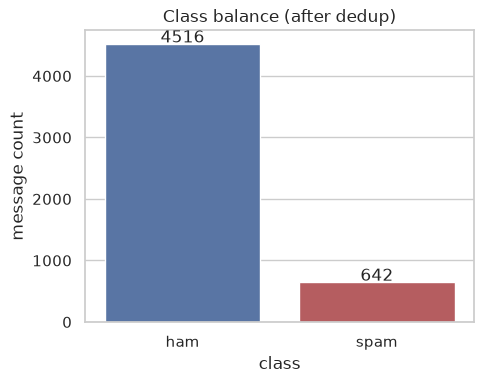

In [4]:
counts = df["label"].map({config.HAM: "ham", config.SPAM: "spam"}).value_counts()
spam_pct = 100 * df["label"].mean()
print(counts.to_string())
print(f"Spam proportion: {spam_pct:.2f}%")

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=["#4c72b0", "#c44e52"], legend=False, ax=ax)
ax.set_title("Class balance (after dedup)")
ax.set_xlabel("class"); ax.set_ylabel("message count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center")
fig.tight_layout()
fig.savefig(RESULTS / "fig_class_balance.png", dpi=150)
plt.show()

## 3. Message length by class

Spam messages are often longer (promotional content, phone numbers, URLs). We measure length in characters and words.

        count        mean        std   min    25%    50%     75%    max
label                                                                  
0      4516.0   70.967006  56.634262   2.0   34.0   53.0   91.25  910.0
1       642.0  137.841121  30.093660  13.0  132.0  148.5  157.00  224.0


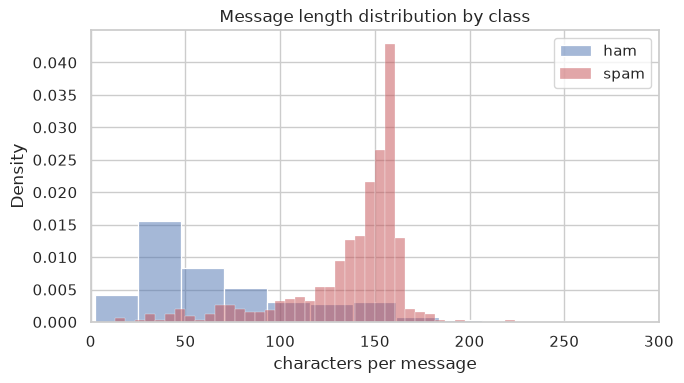

In [5]:
df = df.copy()
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().apply(len)

print(df.groupby("label")["char_len"].describe())

fig, ax = plt.subplots(figsize=(7, 4))
for lbl, name, color in [(config.HAM, "ham", "#4c72b0"), (config.SPAM, "spam", "#c44e52")]:
    sns.histplot(df.loc[df.label == lbl, "char_len"], bins=40, stat="density",
                 label=name, color=color, alpha=0.5, ax=ax)
ax.set_title("Message length distribution by class")
ax.set_xlabel("characters per message"); ax.set_xlim(0, 300)
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS / "fig_length_by_class.png", dpi=150)
plt.show()

## 4. Most frequent words per class

Using `CountVectorizer` with English stopwords removed, on cleaned text, to surface the most *distinctive* frequent tokens in each class.

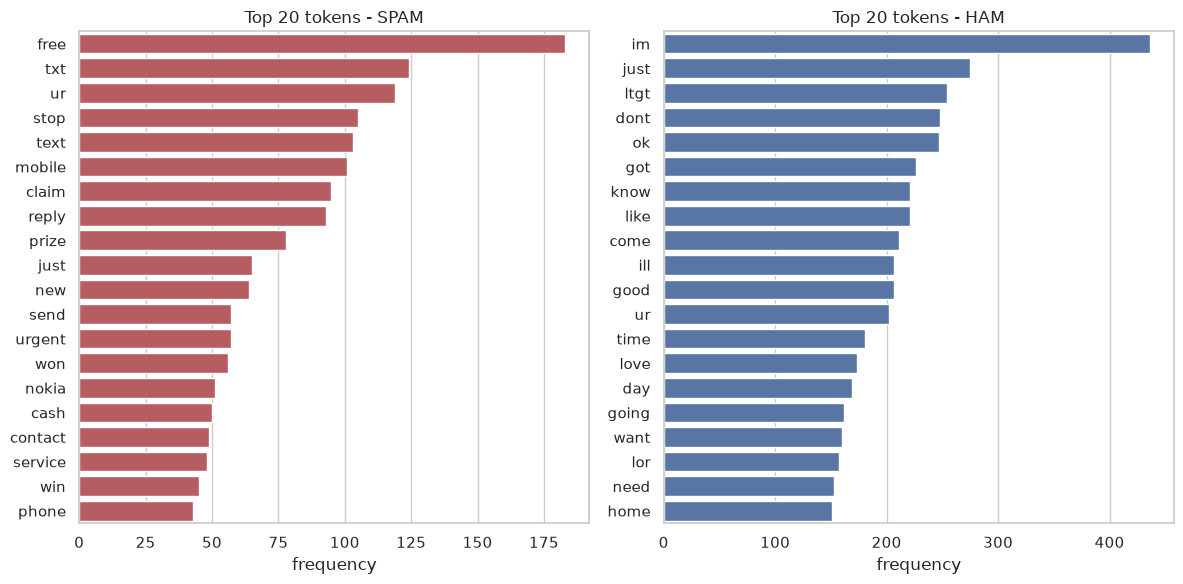

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

def top_tokens(texts, n=20):
    vec = CountVectorizer(stop_words="english")
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    order = freqs.argsort()[::-1][:n]
    return vocab[order], freqs[order]

cleaned = df["text"].apply(lambda t: clean(t))  # default cleaning
spam_tokens, spam_freqs = top_tokens(cleaned[df.label == config.SPAM])
ham_tokens, ham_freqs = top_tokens(cleaned[df.label == config.HAM])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.barplot(x=spam_freqs, y=spam_tokens, ax=axes[0], color="#c44e52")
axes[0].set_title("Top 20 tokens - SPAM")
sns.barplot(x=ham_freqs, y=ham_tokens, ax=axes[1], color="#4c72b0")
axes[1].set_title("Top 20 tokens - HAM")
for a in axes:
    a.set_xlabel("frequency")
fig.tight_layout()
fig.savefig(RESULTS / "fig_top_tokens.png", dpi=150)
plt.show()

## 5. Summary table -> `results/eda_summary.csv`

The single source of truth for the dataset numbers quoted in the report.

In [7]:
summary = {
    "rows_raw": len(raw),
    "rows_dedup": len(df),
    "duplicates_removed": len(raw) - len(df),
    "n_ham": int((df.label == config.HAM).sum()),
    "n_spam": int((df.label == config.SPAM).sum()),
    "spam_pct": round(100 * df.label.mean(), 2),
    "avg_char_len_ham": round(df.loc[df.label == config.HAM, "char_len"].mean(), 1),
    "avg_char_len_spam": round(df.loc[df.label == config.SPAM, "char_len"].mean(), 1),
    "avg_word_len_ham": round(df.loc[df.label == config.HAM, "word_len"].mean(), 1),
    "avg_word_len_spam": round(df.loc[df.label == config.SPAM, "word_len"].mean(), 1),
}
summary_df = pd.DataFrame([summary])
summary_df.to_csv(RESULTS / "eda_summary.csv", index=False)
summary_df.T

,0
rows_raw,5572.00
rows_dedup,5158.00
duplicates_removed,414.00
n_ham,4516.00
n_spam,642.00
spam_pct,12.45
avg_char_len_ham,71.00
avg_char_len_spam,137.80
avg_word_len_ham,14.20
avg_word_len_spam,23.70


## 6. Create & persist the train/test split

One stratified 80/20 split, seed 42, saved to `results/split_indices.npz`. Every later notebook calls `make_split()` and gets this exact split back.

In [8]:
X_train, X_test, y_train, y_test = make_split(df)
print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")
print(f"Train spam %: {100 * y_train.mean():.2f}")
print(f"Test  spam %: {100 * y_test.mean():.2f}")
print(f"Overall spam %: {100 * df.label.mean():.2f}")
print("Saved split to:", config.SPLIT_PATH)
assert abs(y_train.mean() - y_test.mean()) < 0.01, "Split is not stratified!"
print("Stratification check passed.")

Train size: 4126  |  Test size: 1032
Train spam %: 12.46
Test  spam %: 12.40
Overall spam %: 12.45
Saved split to: /home/sdd/Documents/ovi/final year project/results/split_indices.npz
Stratification check passed.
